In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import VGG16
from tensorflow.keras.datasets import cifar10 as cf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [3]:
(x_train, y_train), (x_test, y_test) = cf.load_data()

e:\MCA\.venv-3.11\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
print(x_train.shape)
print(y_train.shape)
print(y_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 1)
(10000, 1)


In [5]:
x_train = x_train/255.0
x_test = x_test/255.0

In [6]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


In [8]:
# freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False
'''
Alternate Method
'''
# Build the model
model = Sequential()

#define the input shape
model.add(InputLayer(input_shape=(32, 32, 3))) # add this line for new image data

# Add the VGG16 base model
model.add(base_model)

#Flatten / Pool the output from VGG16's convolutional layers
# model.add(Flatten()) # this is the original method
model.add(GlobalAveragePooling2D())

#Add a fully connected layer with 256 units and ReLU activation
model.add(Dense(256, activation='relu'))

#Add a dropout layer with a dropout rate of 0.5 for regularization
model.add(Dropout(0.5))

# Add output layer with 10 units (for 10 classes) and softmax activation
model.add(Dense(10, activation='softmax'))

e:\MCA\.venv-3.11\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [9]:
#Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
#print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
# Create data augmentation generator, to reduce overfitting
datagen = ImageDataGenerator(
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)

In [12]:
# Fit the model using data augmentation
train_generator = datagen.flow(x_train, y_train, batch_size = 64)
x_train.shape[0]


50000

In [14]:
history = model.fit(train_generator,steps_per_epoch = x_train.shape[0] // 64,
                    epochs = 3,
                    validation_data = (x_test, y_test),
                    verbose = 1)

Epoch 1/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 94s 121ms/step - accuracy: 0.4834 - loss: 1.4647 - val_accuracy: 0.5518 - val_loss: 1.2848
Epoch 2/3
  1/781 ━━━━━━━━━━━━━━━━━━━━ 1:24 108ms/step - accuracy: 0.4844 - loss: 1.6625

e:\MCA\.venv-3.11\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.4844 - loss: 1.6625 - val_accuracy: 0.5519 - val_loss: 1.2854
Epoch 3/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.5191 - loss: 1.3656 - val_accuracy: 0.5705 - val_loss: 1.2272


In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose = 2)
print('Test accuracy:', test_acc)

313/313 - 16s - 51ms/step - accuracy: 0.5705 - loss: 1.2272
Test accuracy: 0.5705000162124634


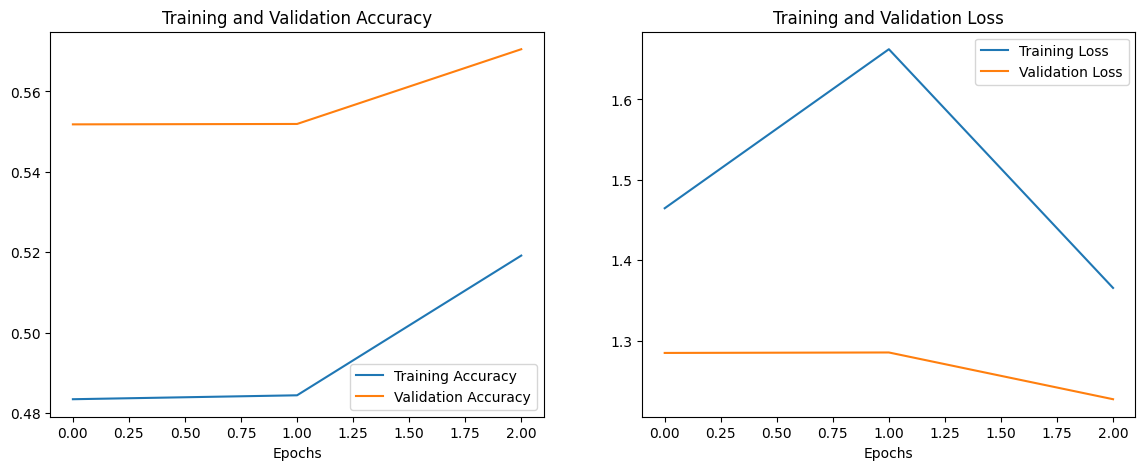

In [16]:
# plotting the training and validation accuracy
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.legend(loc = 'lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()
